<a href="https://colab.research.google.com/github/vchauhan23/ML-Assessment/blob/main/Case_Study_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score
)

from imblearn.over_sampling import SMOTE

from xgboost import XGBClassifier

In [2]:
# LOAD DATA

df = pd.read_csv("train_transaction.csv")

print("Data loaded successfully!")

print("Shape of dataset:", df.shape)

print("\nFirst 5 rows:")
print(df.head())

Data loaded successfully!
Shape of dataset: (5900, 394)

First 5 rows:
   TransactionID  isFraud  TransactionDT  TransactionAmt ProductCD  card1  \
0        2987000        0          86400            68.5         W  13926   
1        2987001        0          86401            29.0         W   2755   
2        2987002        0          86469            59.0         W   4663   
3        2987003        0          86499            50.0         W  18132   
4        2987004        0          86506            50.0         H   4497   

   card2  card3       card4  card5  ... V330  V331  V332  V333  V334 V335  \
0    NaN  150.0    discover  142.0  ...  NaN   NaN   NaN   NaN   NaN  NaN   
1  404.0  150.0  mastercard  102.0  ...  NaN   NaN   NaN   NaN   NaN  NaN   
2  490.0  150.0        visa  166.0  ...  NaN   NaN   NaN   NaN   NaN  NaN   
3  567.0  150.0  mastercard  117.0  ...  NaN   NaN   NaN   NaN   NaN  NaN   
4  514.0  150.0  mastercard  102.0  ...  0.0   0.0   0.0   0.0   0.0  0.0   

  V

In [3]:
# 3. CHECK FRAUD DISTRIBUTION
print("\nFraud distribution:")

print(df["isFraud"].value_counts())

print("\nFraud percentage:")

print(
    df["isFraud"].value_counts(normalize=True) * 100
)


Fraud distribution:
isFraud
0    5755
1     145
Name: count, dtype: int64

Fraud percentage:
isFraud
0    97.542373
1     2.457627
Name: proportion, dtype: float64


In [4]:
# DATA PRE-PROCESSING

df = df.dropna(subset=["isFraud"])
y = df["isFraud"]

In [5]:
# Separate features and target
X = df.drop("isFraud", axis=1)

y = df["isFraud"]

In [6]:
# Remove TransactionID
X = X.drop("TransactionID", axis=1)

In [7]:
# Convert categorical columns into numbers
X = pd.get_dummies(
    X,
    drop_first=True
)

In [8]:
# Handle missing values
X = X.fillna(0)
X = X.astype(float)

In [9]:
# Check the data

print("\nData after preprocessing:")

print("X shape:", X.shape)

print("y shape:", y.shape)

print("Missing values in X:", X.isnull().sum().sum())

print("Missing values in y:", y.isnull().sum())


Data after preprocessing:
X shape: (5900, 467)
y shape: (5900,)
Missing values in X: 0
Missing values in y: 0


In [10]:
# TRAIN-TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


print("\nTraining data:", X_train.shape)

print("Testing data:", X_test.shape)


Training data: (4720, 467)
Testing data: (1180, 467)


In [11]:
# CHECK CLASS IMBALANCE

print("\nClass distribution BEFORE SMOTE:")

print(y_train.value_counts())


Class distribution BEFORE SMOTE:
isFraud
0    4604
1     116
Name: count, dtype: int64


In [12]:
# APPLY SMOTE

smote = SMOTE(
    random_state=42
)


X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)


print("\nClass distribution AFTER SMOTE:")

print(y_train_smote.value_counts())


Class distribution AFTER SMOTE:
isFraud
0    4604
1    4604
Name: count, dtype: int64


In [13]:
# CREATE XGBOOST MODEL

model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss"
)

In [14]:
# TRAIN THE MODEL

print("\nTraining XGBoost model...")

model.fit(
    X_train_smote,
    y_train_smote
)

print("Model training completed!")


Training XGBoost model...
Model training completed!


In [15]:
# PREDICT FRAUD PROBABILITY
y_probability = model.predict_proba(
    X_test
)[:, 1]


print("\nFirst 10 predicted probabilities:")

print(y_probability[:10])


First 10 predicted probabilities:
[0.00330351 0.00104387 0.11148667 0.00270796 0.12102234 0.05173417
 0.01501868 0.0025075  0.00473623 0.00181503]


In [16]:
# ROC-AUC
auc = roc_auc_score(
    y_test,
    y_probability
)

print("\nROC-AUC Score:", auc)


ROC-AUC Score: 0.946163755654753


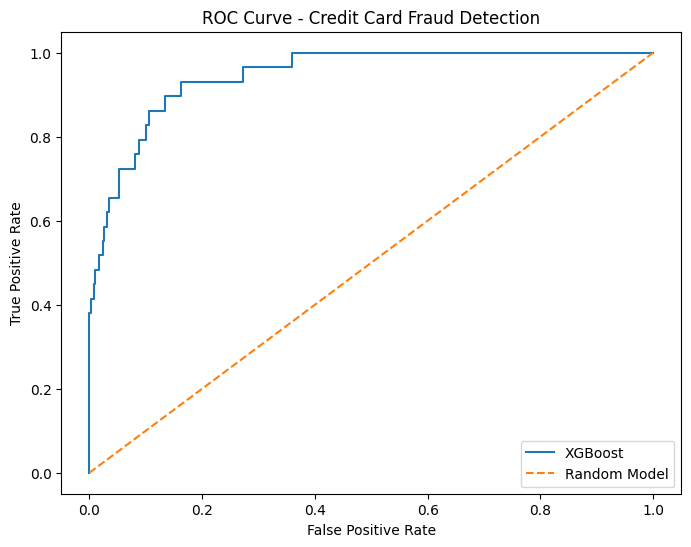

In [17]:
# ROC CURVE

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_probability
)


plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label="XGBoost"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Model"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Credit Card Fraud Detection")

plt.legend()

plt.show()

In [18]:
# PREDICTION USING DEFAULT THRESHOLD

threshold = 0.5

y_prediction = (
    y_probability >= threshold
).astype(int)

In [19]:
# CONFUSION MATRIX
cm = confusion_matrix(
    y_test,
    y_prediction
)


print("\nConfusion Matrix:")

print(cm)


tn, fp, fn, tp = cm.ravel()


print("\nTrue Negatives :", tn)

print("False Positives:", fp)

print("False Negatives:", fn)

print("True Positives :", tp)


Confusion Matrix:
[[1150    1]
 [  18   11]]

True Negatives : 1150
False Positives: 1
False Negatives: 18
True Positives : 11


In [20]:
# PRECISION AND RECALL
precision = precision_score(
    y_test,
    y_prediction,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_prediction,
    zero_division=0
)


print("\nPrecision:", precision)

print("Recall:", recall)


Precision: 0.9166666666666666
Recall: 0.3793103448275862


In [21]:
# CLASSIFICATION REPORT
print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_prediction,
        zero_division=0
    )
)


Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1151
           1       0.92      0.38      0.54        29

    accuracy                           0.98      1180
   macro avg       0.95      0.69      0.76      1180
weighted avg       0.98      0.98      0.98      1180



In [22]:
# THRESHOLD TUNING
thresholds_to_test = [
    0.10,
    0.20,
    0.30,
    0.40,
    0.50,
    0.60,
    0.70,
    0.80,
    0.90
]


print("\n====================================")

print("THRESHOLD TUNING")

print("====================================")


for threshold in thresholds_to_test:

    prediction = (
        y_probability >= threshold
    ).astype(int)

    cm = confusion_matrix(
        y_test,
        prediction
    )

    tn, fp, fn, tp = cm.ravel()

    precision = precision_score(
        y_test,
        prediction,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        prediction,
        zero_division=0
    )

    print("\nThreshold:", threshold)

    print("False Positives:", fp)

    print("False Negatives:", fn)

    print("Precision:", precision)

    print("Recall:", recall)


THRESHOLD TUNING

Threshold: 0.1
False Positives: 30
False Negatives: 12
Precision: 0.3617021276595745
Recall: 0.5862068965517241

Threshold: 0.2
False Positives: 11
False Negatives: 16
Precision: 0.5416666666666666
Recall: 0.4482758620689655

Threshold: 0.3
False Positives: 6
False Negatives: 17
Precision: 0.6666666666666666
Recall: 0.41379310344827586

Threshold: 0.4
False Positives: 3
False Negatives: 18
Precision: 0.7857142857142857
Recall: 0.3793103448275862

Threshold: 0.5
False Positives: 1
False Negatives: 18
Precision: 0.9166666666666666
Recall: 0.3793103448275862

Threshold: 0.6
False Positives: 0
False Negatives: 18
Precision: 1.0
Recall: 0.3793103448275862

Threshold: 0.7
False Positives: 0
False Negatives: 18
Precision: 1.0
Recall: 0.3793103448275862

Threshold: 0.8
False Positives: 0
False Negatives: 20
Precision: 1.0
Recall: 0.3103448275862069

Threshold: 0.9
False Positives: 0
False Negatives: 21
Precision: 1.0
Recall: 0.27586206896551724


In [23]:
# SELECT A NEW THRESHOLD
selected_threshold = 0.30


y_prediction_tuned = (
    y_probability >= selected_threshold
).astype(int)

In [24]:
# CONFUSION MATRIX AFTER THRESHOLD TUNING
cm_tuned = confusion_matrix(
    y_test,
    y_prediction_tuned
)


print("\n====================================")

print("AFTER THRESHOLD TUNING")

print("====================================")


print("\nSelected Threshold:", selected_threshold)

print("\nConfusion Matrix:")

print(cm_tuned)


tn, fp, fn, tp = cm_tuned.ravel()


print("\nTrue Negatives :", tn)

print("False Positives:", fp)

print("False Negatives:", fn)

print("True Positives :", tp)


AFTER THRESHOLD TUNING

Selected Threshold: 0.3

Confusion Matrix:
[[1145    6]
 [  17   12]]

True Negatives : 1145
False Positives: 6
False Negatives: 17
True Positives : 12


In [25]:
# PRECISION AND RECALL AFTER TUNING
precision_tuned = precision_score(
    y_test,
    y_prediction_tuned,
    zero_division=0
)

recall_tuned = recall_score(
    y_test,
    y_prediction_tuned,
    zero_division=0
)


print("\nPrecision after tuning:", precision_tuned)

print("Recall after tuning:", recall_tuned)


Precision after tuning: 0.6666666666666666
Recall after tuning: 0.41379310344827586


In [26]:
# FEATURE IMPORTANCE
importance = model.feature_importances_


feature_importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": importance

})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)


print("\n====================================")

print("TOP 20 IMPORTANT FEATURES")

print("====================================")


print(
    feature_importance.head(20)
)


TOP 20 IMPORTANT FEATURES
         Feature  Importance
13            C4    0.141649
330         V292    0.086492
109          V71    0.039868
331         V293    0.038629
101          V63    0.038267
328         V290    0.028904
11            C2    0.026087
135          V97    0.023707
385  card6_debit    0.022465
206         V168    0.020679
177         V139    0.016432
326         V288    0.015061
369         V331    0.014046
20           C11    0.013961
92           V54    0.013849
270         V232    0.012814
121          V83    0.012653
209         V171    0.012610
260         V222    0.011636
355         V317    0.011043


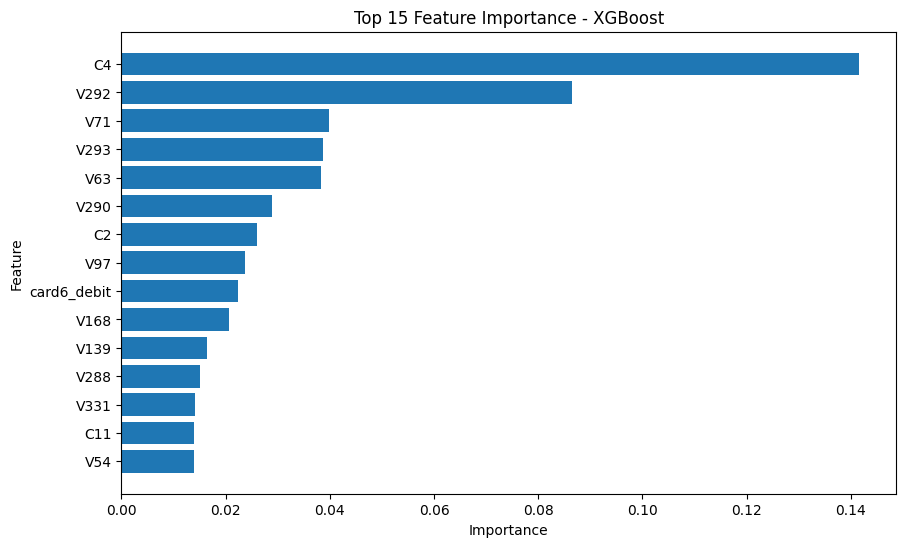

In [27]:
# FEATURE IMPORTANCE GRAPH
top_features = feature_importance.head(15)


plt.figure(figsize=(10, 6))


plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)


plt.xlabel("Importance")

plt.ylabel("Feature")

plt.title("Top 15 Feature Importance - XGBoost")


plt.gca().invert_yaxis()


plt.show()

In [28]:
#  FINAL RESULTS
print("\n====================================")

print("FINAL RESULTS")

print("====================================")


print("ROC-AUC:", auc)

print("Selected Threshold:", selected_threshold)

print("False Positives:", fp)

print("False Negatives:", fn)

print("Precision:", precision_tuned)

print("Recall:", recall_tuned)


FINAL RESULTS
ROC-AUC: 0.946163755654753
Selected Threshold: 0.3
False Positives: 6
False Negatives: 17
Precision: 0.6666666666666666
Recall: 0.41379310344827586
